# generate 1000 data points in R^2 with Patnaik-Pearson dimension = 1.5

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [3]:
# !pip install pandas

In [5]:
import PatnaikPearson as pp
import cupy

In [9]:
N = 1000
d = 2
lambda1 = 1.0
lambda2 = 2.0 + math.sqrt(3.0)
Lambda = np.diag([lambda1, lambda2])
print(Lambda)
print(pp.calculate_nu(Lambda))

X = np.random.normal(loc = 0.0, scale = 1.0, size=(N,d)) @ Lambda

#rotate through 45 degrees
this_cos = 1.0 / math.sqrt(2)
this_sin = 1.0 / math.sqrt(2)
Q = np.array([[this_cos, -this_sin], [this_sin, this_cos]])
X = X @ Q

pp_dim = pp.calculate_PatnaikPearson_dim(X, verbose=False)
print("pp_dim = ", pp_dim)

nu, two_nn_dim = pp.calculate_nu_twonn_dim(X, verbose=False)
print("nu = ", nu)
print("two_nn_dim = ", two_nn_dim)

[[1.         0.        ]
 [0.         3.73205081]]
** calculate_nu_gpu ** running on GPU
1.4999999999999998
** calculate_nu_gpu ** running on GPU
pp_dim =  1.5144745860991278
** calculate_nu_gpu ** running on GPU
nu =  1.514474586099128
two_nn_dim =  1.942781085609804


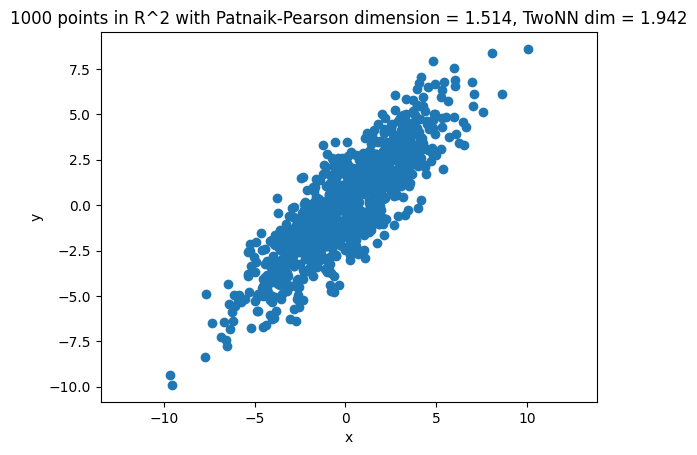

In [12]:
x_vals = X[:,0]
y_vals = X[:,1]

scale_factor = 1000.0
this_pp_dim = ((int) (pp_dim * scale_factor)) / scale_factor
this_two_nn_dim = ((int) (two_nn_dim * scale_factor)) / scale_factor

this_title = str(N) + " points in R^2 with Patnaik-Pearson dimension = " + str(this_pp_dim) + ", TwoNN dim = " + str(this_two_nn_dim)
plt.scatter(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.title(this_title)
plt.axis('equal')
#plt.savefig('R_2_pp_dim_eq_1_514_N_eq_1000.pdf', dpi=300, bbox_inches='tight')
plt.show()